In [152]:
# Using linear regression (single or Multiple)
# Performing at least three 'groupby' functions based on Polars library
import matplotlib.pyplot as plt
import polars as pl
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import accuracy_score

In [153]:
df = pd.read_csv('insurance.csv') # importing the dataset
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [154]:
df.shape

(1338, 7)

In [155]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [156]:
df.isnull().sum() # Checking if there is any missing, No missing values

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [157]:
# DATA ANALYSIS
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


C:\Users\WIN 10\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


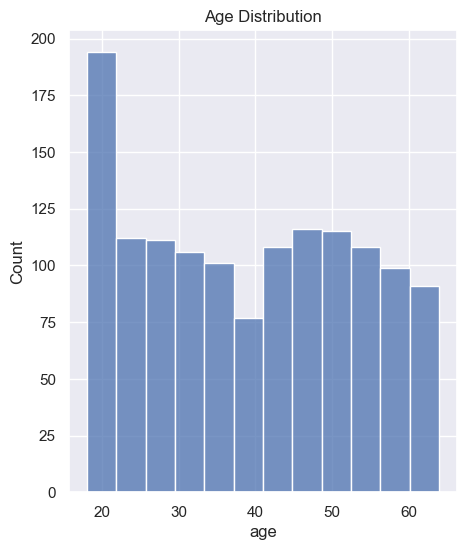

In [158]:
# SHOW THE DISTRIBUTION OF NUMERICAL COLUMNS (age, bmi, children)
sns.set()
plt.figure(figsize=(5,6))  # Set the figure size first
sns.histplot(df['age'])
plt.title('Age Distribution')
plt.show()

C:\Users\WIN 10\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


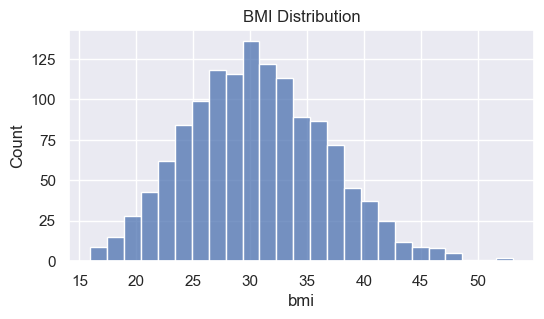

In [159]:
plt.figure(figsize=(6,3))
sns.histplot(df['bmi'])
plt.title('BMI Distribution')
plt.show()
# normal BMI ---> 18.5 to 24.9 

children
0    574
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64


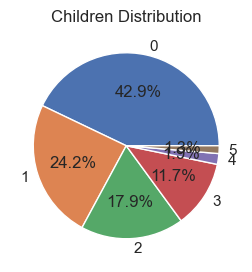

In [160]:
plt.figure(figsize=(3,4))
children_counts = df['children'].value_counts()
print(children_counts)
plt.pie(children_counts, labels=children_counts.index, autopct='%1.1f%%')
plt.title('Children Distribution')
plt.show()

In [161]:
# SHOW THE DISTRIBTUTION OF CATEGORICAL VARIABLES (gender, smoker, region)
# Distribution in gender (sex)
gender_counts = df['sex'].value_counts()
print(gender_counts)

sex
male      676
female    662
Name: count, dtype: int64


<Figure size 500x700 with 0 Axes>

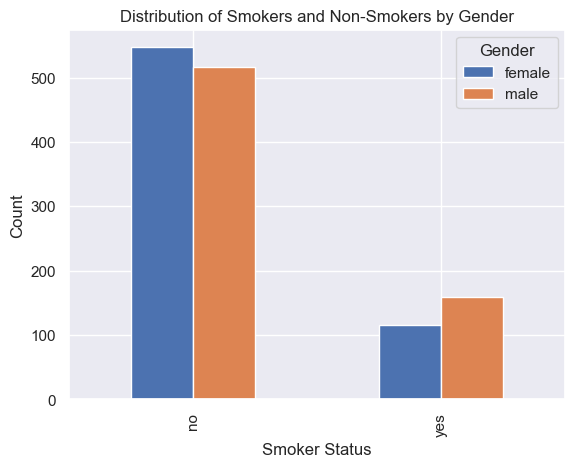

In [162]:
# Count the number of smokers and non-smokers for each gender
smoker_gender_counts = df.groupby(['smoker', 'sex']).size().unstack()
plt.figure(figsize=(5, 7))
smoker_gender_counts.plot(kind='bar')
plt.title('Distribution of Smokers and Non-Smokers by Gender')
plt.xlabel('Smoker Status')
plt.ylabel('Count')
plt.legend(title='Gender')
plt.show()

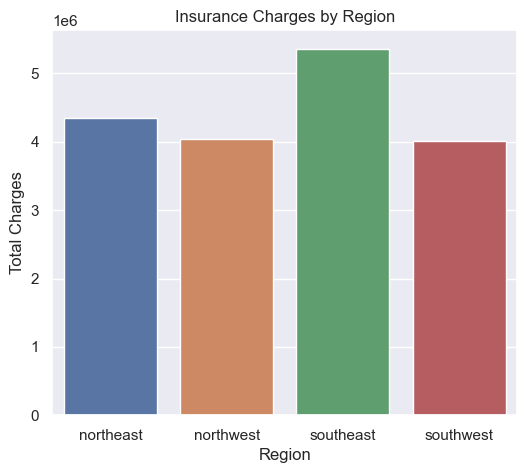

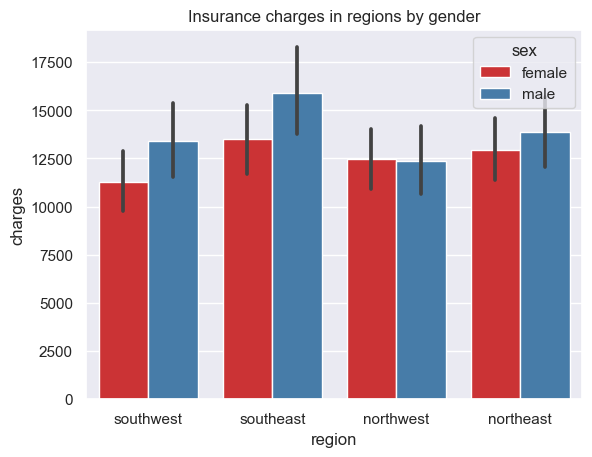

Text(0.5, 1.0, 'Insurance charges in regions by smoking status ')

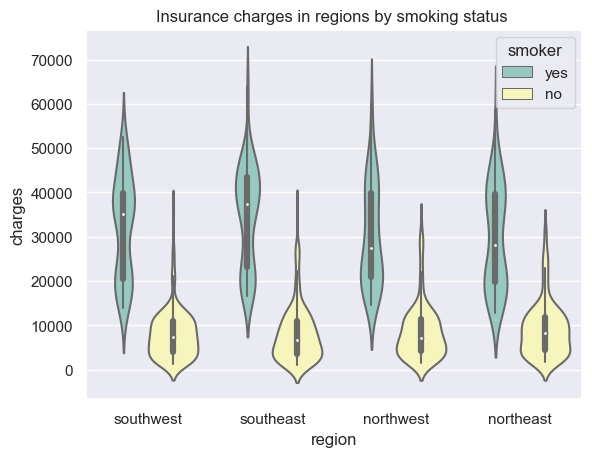

In [163]:
charges_by_region = df.groupby('region', as_index=False)['charges'].sum()
# Create the bar plot
plt.figure(figsize=(6, 5))
sns.barplot(x='region', y='charges', data=charges_by_region)
plt.title('Insurance Charges by Region')
plt.xlabel('Region')
plt.ylabel('Total Charges')
plt.show()

# Analyse in certain factors
## in gender
sns.barplot(x='region', y='charges', hue='sex', data=df, palette='Set1')
plt.title('Insurance charges in regions by gender')
plt.show()
## in smoker
sns.violinplot(x='region', y='charges', hue='smoker', data=df, palette='Set3')
plt.title('Insurance charges in regions by smoking status ')


C:\Users\WIN 10\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Text(0.5, 1.0, 'Distribution of Charges')

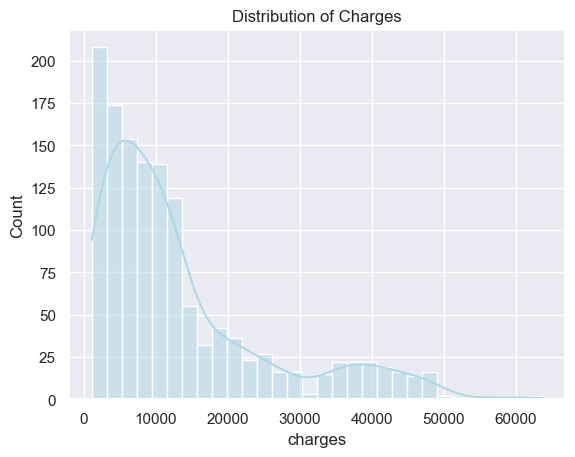

In [164]:
# SHOW THE DISTRIBUTION OF DEPENDENT VARIABLES (charges)
sns.histplot(df['charges'], color = 'lightblue', kde=True)
plt.xlabel('charges')
plt.title('Distribution of Charges')

In [165]:
# Using polars library to read the 'insurance_csv' file
df_pl = pl.read_csv('insurance.csv')
df_pl.head()

age,sex,bmi,children,smoker,region,charges
i64,str,f64,i64,str,str,f64
19,"""female""",27.9,0,"""yes""","""southwest""",16884.924
18,"""male""",33.77,1,"""no""","""southeast""",1725.5523
28,"""male""",33.0,3,"""no""","""southeast""",4449.462
33,"""male""",22.705,0,"""no""","""northwest""",21984.47061
32,"""male""",28.88,0,"""no""","""northwest""",3866.8552


shape: (2, 2)
┌────────┬───────────────────────────┐
│ smoker ┆ Average charges by smoker │
│ ---    ┆ ---                       │
│ str    ┆ f64                       │
╞════════╪═══════════════════════════╡
│ no     ┆ 8434.268298               │
│ yes    ┆ 32050.231832              │
└────────┴───────────────────────────┘
shape: (2, 2)
┌────────┬─────────────────────────┐
│ smoker ┆ Total charges by smoker │
│ ---    ┆ ---                     │
│ str    ┆ f64                     │
╞════════╪═════════════════════════╡
│ no     ┆ 8.9741e6                │
│ yes    ┆ 8.7818e6                │
└────────┴─────────────────────────┘


C:\Users\WIN 10\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


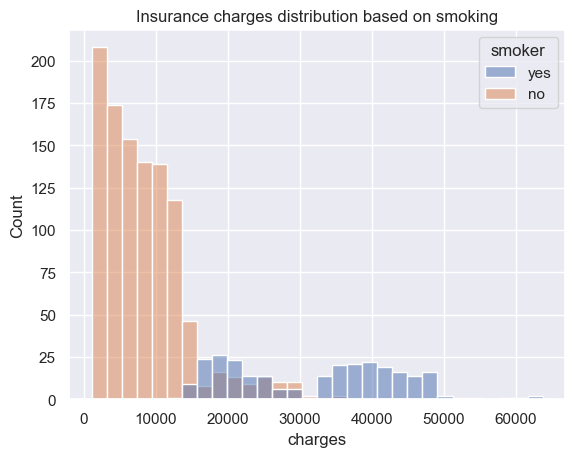

In [166]:
#SMOKING
# Average the insurance charges by smoker
ave_charges_bysmoker = df_pl.group_by('smoker').agg(pl.col('charges').mean().alias('Average charges by smoker'))
print(ave_charges_bysmoker)
# The different charges distribution based on smoker
tl_charges_bysmoker = df_pl.group_by('smoker').agg(pl.col('charges').sum().alias('Total charges by smoker'))
print(tl_charges_bysmoker)
sns.histplot(x=df['charges'], hue=df['smoker'])
plt.title('Insurance charges distribution based on smoking')
plt.show()

shape: (1, 1)
┌─────────────────────────────────┐
│ Average charges for underweigh… │
│ ---                             │
│ f64                             │
╞═════════════════════════════════╡
│ 8657.620652                     │
└─────────────────────────────────┘
shape: (1, 1)
┌────────────────────────────────┐
│ Average charges for overweight │
│ ---                            │
│ f64                            │
╞════════════════════════════════╡
│ 13946.476035                   │
└────────────────────────────────┘
shape: (1, 1)
┌─────────────────────────────────┐
│ Average charges for normalweig… │
│ ---                             │
│ f64                             │
╞═════════════════════════════════╡
│ 10435.440719                    │
└─────────────────────────────────┘


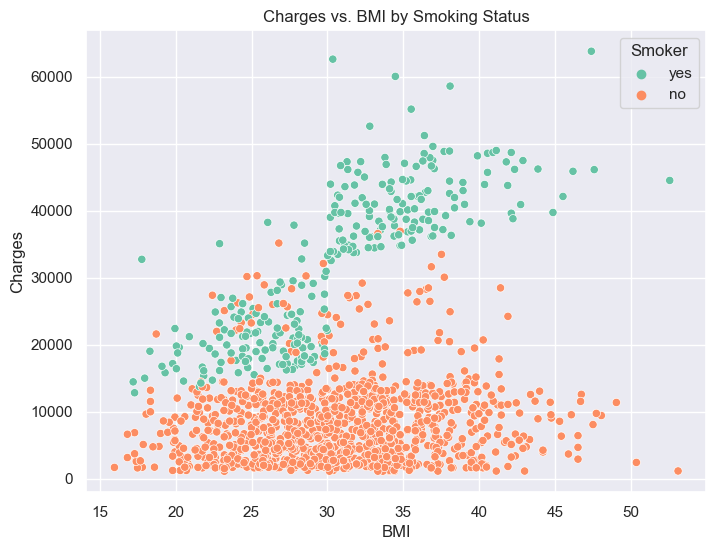

In [167]:
#BMI
# Category the BMI into 3 types and calculate mean of each type
underweight_df = df_pl.select(pl.col(['bmi' , 'charges']).filter(pl.col('bmi')<=18.5))
underweight_df
ave_charges_underweight = underweight_df.select(pl.col('charges').mean().alias('Average charges for underweight'))
print(ave_charges_underweight)

overweight_df = df_pl.select(pl.col(['bmi' , 'charges']).filter(pl.col('bmi')>25))
overweight_df
ave_charges_overweight = overweight_df.select(pl.col('charges').mean().alias('Average charges for overweight'))
print(ave_charges_overweight)

normalweight_df = df_pl.filter((pl.col('bmi') > 18.5) & (pl.col('bmi') <= 25)
                              ).select(['bmi', 'charges'])
ave_charges_normalweight = normalweight_df.select(pl.col('charges').mean().alias('Average charges for normalweight'))
print(ave_charges_normalweight)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_pl, x='bmi', y='charges', hue='smoker', palette='Set2')
plt.title('Charges vs. BMI by Smoking Status')
plt.xlabel('BMI')
plt.ylabel('Charges')
plt.legend(title='Smoker')
plt.show()

shape: (1, 1)
┌─────────────────────────────┐
│ Average charges for under25 │
│ ---                         │
│ f64                         │
╞═════════════════════════════╡
│ 9087.015807                 │
└─────────────────────────────┘
shape: (1, 1)
┌─────────────────────────────┐
│ Average charges for under35 │
│ ---                         │
│ f64                         │
╞═════════════════════════════╡
│ 10495.163047                │
└─────────────────────────────┘
shape: (1, 1)
┌─────────────────────────────┐
│ Average charges for under45 │
│ ---                         │
│ f64                         │
╞═════════════════════════════╡
│ 13493.485247                │
└─────────────────────────────┘
shape: (1, 1)
┌─────────────────────────────┐
│ Average charges for under55 │
│ ---                         │
│ f64                         │
╞═════════════════════════════╡
│ 15986.90031                 │
└─────────────────────────────┘
shape: (1, 1)
┌────────────────────────────┐
│ A

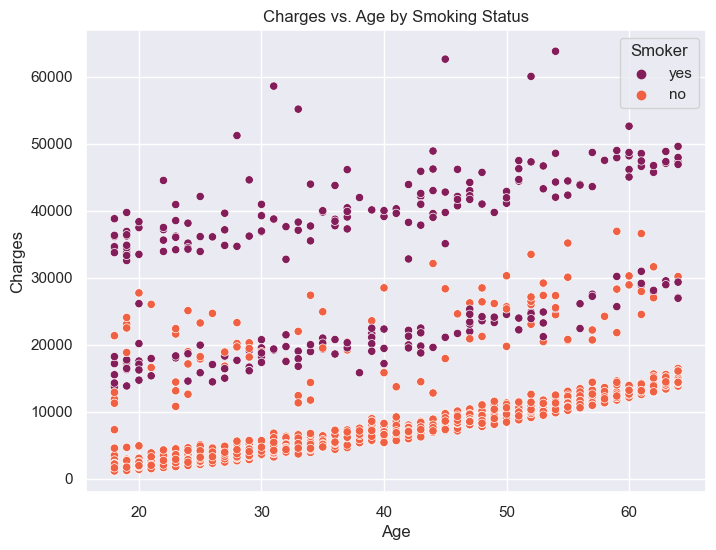

In [168]:
# AGE
under25_df = df_pl.select(pl.col(['age' , 'charges']).filter(pl.col('age')<=25))
under25_df
ave_charges_under25 = under25_df.select(pl.col('charges').mean().alias('Average charges for under25'))
print(ave_charges_under25)

under35_df = df_pl.select(pl.col(['age' , 'charges']).filter((pl.col('age') > 25) & (pl.col('age') <= 35)))
under35_df
ave_charges_under35 = under35_df.select(pl.col('charges').mean().alias('Average charges for under35'))
print(ave_charges_under35)

under45_df = df_pl.select(pl.col(['age' , 'charges']).filter((pl.col('age') > 35) & (pl.col('age') <= 45)))
under45_df
ave_charges_under45 = under45_df.select(pl.col('charges').mean().alias('Average charges for under45'))
print(ave_charges_under45)

under55_df = df_pl.select(pl.col(['age' , 'charges']).filter((pl.col('age') > 45) & (pl.col('age') <= 55)))
under55_df
ave_charges_under55 = under55_df.select(pl.col('charges').mean().alias('Average charges for under55'))
print(ave_charges_under55)

over55_df = df_pl.select(pl.col(['age' , 'charges']).filter((pl.col('age') > 55) ))
over55_df
ave_charges_over55 = over55_df.select(pl.col('charges').mean().alias('Average charges for over55'))
print(ave_charges_over55)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='age', y='charges', hue='smoker', palette='rocket')
plt.title('Charges vs. Age by Smoking Status')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.legend(title='Smoker')
plt.show()

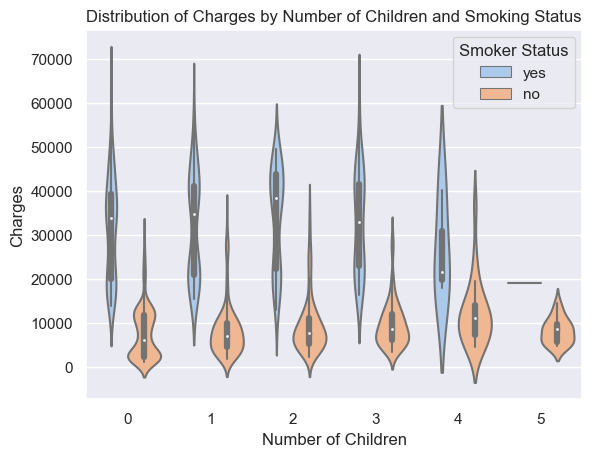

In [169]:
# CHILDREN
sns.violinplot(x='children', y='charges', data=df,
               orient='v', hue='smoker', palette='pastel')
plt.title('Distribution of Charges by Number of Children and Smoking Status')
plt.xlabel('Number of Children')
plt.ylabel('Charges')
plt.legend(title='Smoker Status')
plt.show()

In [170]:
# DATA PREPROCESSING
## encoding the categorical variables
df.replace({'sex':{'male':0,'female':1}}, inplace=True)
df.replace({'smoker':{'yes':1,'no':0}}, inplace=True)
df.replace({'region':{'southeast':0,'southwest':1,'northeast':2,'northwest':3}}, inplace=True)

In [171]:
# MACHINE LEARNING _ LINEAR REGRESSION
X= df[['age', 'sex','bmi','children','smoker','region']]
Y=df[['charges']]
print(X.head())
print(Y.head())
X_train, X_test, Y_train, Y_test = train_test_split (X ,Y, test_size = 0.3, random_state = 3)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("Y_train:", Y_train.shape)
print("Y_test:", Y_test.shape)

   age  sex     bmi  children  smoker  region
0   19    1  27.900         0       1       1
1   18    0  33.770         1       0       0
2   28    0  33.000         3       0       0
3   33    0  22.705         0       0       3
4   32    0  28.880         0       0       3
       charges
0  16884.92400
1   1725.55230
2   4449.46200
3  21984.47061
4   3866.85520
X_train: (936, 6)
X_test: (402, 6)
Y_train: (936, 1)
Y_test: (402, 1)


In [172]:
# Build model _ linear regression model
reg = LinearRegression()
reg.fit(X_train, Y_train)
print(f'the interpret value: {reg.intercept_}')
print(f'the coefficient for each variable: {reg.coef_}')
print(f'R^square for training data: {reg.score(X_train, Y_train)}') # R^square value traing data
print(f'R^square for testing data: {reg.score(X_test, Y_test)}') # R^square value for testing data
reg.predict(np.array([60, 0, 30, 5, 0, 0]).reshape(1, 6)) # Predict charges with specific values

the interpret value: [-13299.64129718]
the coefficient for each variable: [[  253.13748879   227.57372091   349.69180078   579.10466192
  24090.324089     199.46704261]]
R^square for training data: 0.7574340926271486
R^square for testing data: 0.7318630535235593


C:\Users\WIN 10\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[15274.88536302]])